<a href="https://colab.research.google.com/github/tomlough/CE5012/blob/main/CE5012_Assignment3_24349976_tomoloughlin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Student Number : 24349976

Student Name : Thomas O Loughlin

# CE5012 Assignment 3:
The assignment notebook should be named following the convention 'student_id_CE5012_Assignment3.ipynb'.

## Part-1:

This week’s assignment involves an in-depth exploration of two major research works in foundation models: Masked Auto Encoders (MAE) and OpenAI's CLIP.

MAE: https://arxiv.org/abs/2111.06377

OpenAI CLIP: https://openai.com/research/clip

During our lecture, we discussed four different methodologies employed to build large-scale vision foundation models:

*   Contrastive Learning → SimCLR
*   Knowledge Distillation → DINO
*   Token Masking → MAE
*   Vision-Language Fusion → CLIP

We covered only the first two models in our lectures. Now, as part of the assignment, you are required to understand the remaining two models, MAEs and CLIP, in detail and prepare notes on each topic. Your notes should be part of the notebook and should cover the following major points:

- A quick overview of the architecture.

- The training strategies used.

- Loss functions employed.

- Key differences between the MAEs and CLIP architectures (2 to 3 points).


This is a significant topic, and hence, some of the questions in the QUIZ will be on these foundation models.

## Evaluation Criteria:

1. 3 points: MAE Presentation
2. 3 points: CLIP Presentation
3. 4 points: Key differences between MAE and CLIP



## Your Part-1 Work Starts From Here

** Ends Here **

# Part-2

The aim is to utilize the pre-trained DINO and CLIP models for feature extraction on three specific classes: airplanes, bonsai trees, and butterflies. We will then visualize these features in a lower dimension using t-SNE (t-Distributed Stochastic Neighbor Embedding). The expected outcome is to observe three distinct clusters, each corresponding to a specific class, even though the models haven't been trained on this particular dataset.

## Explanation:

1. We will leverage pre-trained DINO and CLIP models to extract features from images belonging to the three target classes. These extracted features represent the characteristics learned by the models to identify objects in images.
2. t-SNE, a dimensionality reduction technique, will be used to project these high-dimensional features into a lower-dimensional space for visualization.
3. Ideally, the visualization will reveal three separate clusters, where each cluster groups images belonging to the same class (airplanes, bonsai, or butterflies). This would demonstrate the models' ability to capture class-specific information even without being trained on this specific dataset.

## Additional Notes:

1. The provided notebook should guide you through the detailed steps of implementing this objective.
2. This approach assumes that the pre-trained models have learned generic features that can be applied to classify unseen data, even if not explicitly trained on the specific classes of interest.

## Evaluation Criteria:

1. 3 points: DINO feature visualization clearly separates the three classes.
2. 3 points: CLIP feature visualization clearly separates the three classes.
3. 4 points: Identify and discuss failure cases using your own images. This demonstrates a deeper understanding of the limitations of the models and the potential challenges with generalizability.



In [ ]:
# Required for openAI CLIP
! pip install ftfy regex tqdm
! pip install git+https://github.com/openai/CLIP.git

  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-d4lc1n75
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-d4lc1n75
  Resolved https://github.com/openai/CLIP.git to commit dcba3cb2e2827b402d2701e7e1c7d9fed8a20ef1
  Preparing metadata (setup.py) ... done
  Using cached nvidia_cuda_nvrtc_cu12-12.4.127-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_runtime_cu12-12.4.127-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_cupti_cu12-12.4.127-py3-none-manylinux2014_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cudnn_cu12-9.1.0.70-py3-none-manylinux2014_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cublas_cu12-12.4.5.8-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cufft_cu12-11.2.1.3-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_curand_cu12-10.3.5.147-py3-none-manylinux2014_x86_64.whl.metadat

In [ ]:
# Import the modules needed

# File IO
import os
import zipfile

# PyTorch related
import torch
import torchvision.transforms as transforms
from torchvision.datasets import Caltech101
from torch.utils.data import DataLoader

# Visualization
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image


In [ ]:
# Function to load dataset from zip file
# Note: Please download the dataset from the assignment page

def load_dataset_from_zip(zip_path, transform):
    images = []
    targets = []
    targets_name = []

    class_to_id = {}  # Dictionary to map class names to class IDs
    next_id = 0  # Counter for assigning class IDs

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        for class_name in zip_ref.namelist():
            if class_name.endswith('/'):  # Skip directories
                continue
            class_images = zip_ref.open(class_name)
            image = Image.open(class_images).convert("RGB")
            images.append(transform(image))

            # Extract class name and convert to class ID
            class_name = os.path.basename(os.path.dirname(class_name))
            if class_name not in class_to_id:
                class_to_id[class_name] = next_id
                next_id += 1
            class_id = class_to_id[class_name]

            targets.append(class_id)
            targets_name.append(class_name)

    return images, targets, targets_name

# Define transformations for image pre-processing
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# Function to display images with labels
def display_few_samples(images, labels, num_images_per_class=3):
    unique_labels = set(labels)

    # Create subplots
    fig, axes = plt.subplots(len(unique_labels), num_images_per_class, figsize=(15, 3*len(unique_labels)))

    # Display images for each class
    for i, label in enumerate(unique_labels):
        # Find indices of images belonging to the current class
        class_indices = [idx for idx, lbl in enumerate(labels) if lbl == label]

        # Select two random indices from the class
        selected_indices = np.random.choice(class_indices, size=min(len(class_indices), num_images_per_class), replace=False)

        # Display images
        for j, idx in enumerate(selected_indices):
            image = images[idx].permute(1, 2, 0)  # Convert (C, H, W) to (H, W, C)
            axes[i, j].imshow(image)
            axes[i, j].set_title(label)
            axes[i, j].axis('off')

    plt.tight_layout()
    plt.show()

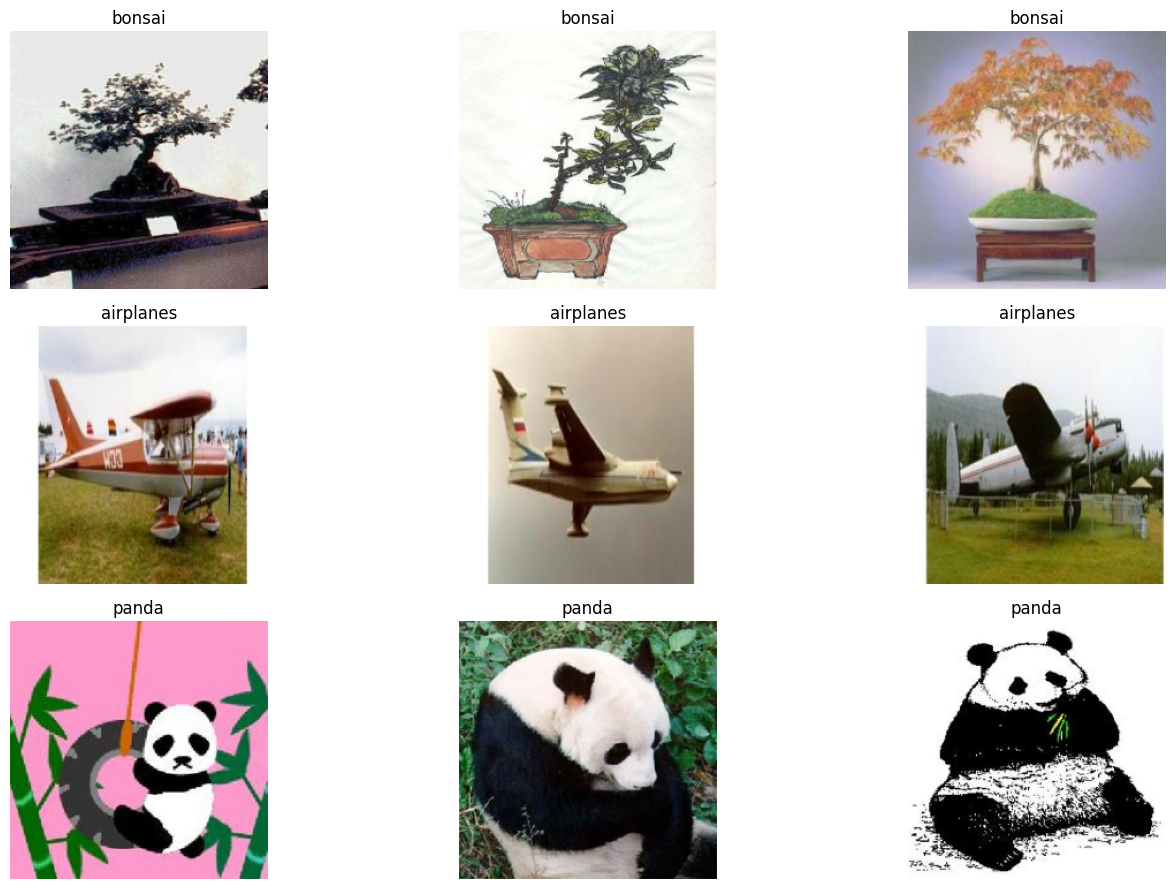

In [ ]:
# Load dataset from zip file
zip_path = "/content/CE5012_Assignment_Dataset.zip"  # Specify the path to your zip file

images, targets, targets_name = load_dataset_from_zip(zip_path, transform)

display_few_samples(images, targets_name)

In [ ]:
# Define class names
class_names = ['airplanes', 'bonsai', 'butterfly']

## Your Part-2 Work Starts From Here

1. Define data loader
2. Load model
3. Extract the features
4. Convert them to numpy format
5. Reduce dimensionality of features using t-SNE
6. Plot t-SNE visualization as a 2D plot
**Note**: use label feature in plt.scatter to display class names as legends


In [ ]:
# Imports
from transformers import CLIPProcessor, CLIPModel
from torchvision.models import resnet50, ResNet50_Weights
from sklearn.manifold import TSNE